# Clase 2 — Práctica Individual resuelta
## Tu primer análisis de datos
### Maestría en Fintech · ITBA · 2026

---

Una forma de resolver los 10 ejercicios de `Clase_2_Practica_Individual.ipynb`, con la **lectura de negocio** de cada uno.

> **Hay más de un camino correcto.** Si llegaste al mismo resultado por otra vía, está bien. Y si todavía no la intentaste, hacelo primero: mirar la solución antes es como leer el final de la película.

Ejecutá **`Entorno de ejecución → Ejecutar todo`**: los datos se descargan solos del repo del curso.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)

DATOS = 'https://raw.githubusercontent.com/camilojaure/itba-pad/main/datasets/'
df = pd.read_csv(DATOS + 'clientes.csv')
print(f'{len(df):,} clientes cargados')

1,000 clientes cargados


---
## Ejercicio 1 · Calentamiento

Clientes por provincia, de mayor a menor.

In [2]:
por_provincia = df['provincia'].value_counts()
print(por_provincia)

top3 = por_provincia.head(3).sum() / len(df)
print(f'\nLas 3 primeras provincias concentran el {top3:.1%} de la cartera')

provincia
CABA            275
Buenos Aires    268
Córdoba         153
Santa Fe        113
Mendoza          81
Entre Ríos       65
Tucumán          45
Name: count, dtype: int64

Las 3 primeras provincias concentran el 69.6% de la cartera


**Lectura esperada:** la cartera está muy concentrada geográficamente. Las primeras dos o tres provincias
explican la mayor parte del negocio — eso condiciona dónde tiene sentido invertir en captación y dónde no.

*Error frecuente:* usar `.count()` en vez de `.value_counts()`.

---
## Ejercicio 2 · Proporciones

Porcentaje de clientes activos.

In [3]:
pct_activos = df['cliente_activo'].mean() * 100
print(f'Clientes activos: {pct_activos:.1f}%')
print()
print(df['cliente_activo'].value_counts())

Clientes activos: 74.5%

cliente_activo
True     745
False    255
Name: count, dtype: int64


**Lectura esperada:** el número importa menos que el concepto — *base declarada* no es lo mismo que
*base que opera*. Si un tercio de la cartera no está activa, todo KPI calculado sobre el total está diluido.

**El truco:** como la columna es booleana (0/1), **el promedio ES la proporción**.
No hace falta contar y dividir. Es el mismo truco que usamos con `churn` en la guiada.

---
## Ejercicio 3 · Los extremos de la cartera

Máximo, mínimo, mediana y media del balance.

In [4]:
print(f"Máximo:  ${df['balance_ars'].max():>12,.0f}")
print(f"Mínimo:  ${df['balance_ars'].min():>12,.0f}")
print(f"Mediana: ${df['balance_ars'].median():>12,.0f}")
print(f"Media:   ${df['balance_ars'].mean():>12,.0f}")

ratio = df['balance_ars'].mean() / df['balance_ars'].median()
print(f'\nLa media es {ratio:.2f}x la mediana')

Máximo:  $  14,118,000
Mínimo:  $       4,300
Mediana: $     211,000
Media:   $     692,892

La media es 3.28x la mediana


**Lectura esperada:** comparar media contra mediana es el reflejo que queremos instalar. Si la media
es bastante mayor, hay pocos clientes muy grandes tirando del promedio, y reportar *"el balance promedio"*
sin aclararlo induce a error.

---
## Ejercicio 4 · Perfil por segmento

Edad, balance y antigüedad promedio por segmento.

In [5]:
perfil_seg = df.groupby('segmento')[['edad', 'balance_ars', 'antiguedad_años']].mean().round(1)
print(perfil_seg)

          edad  balance_ars  antiguedad_años
segmento                                    
Joven     23.3      65099.6              1.2
Premium   51.9    2273940.0              8.5
PyME      43.8     994116.2              5.7
Retail    43.0     259286.9              4.3


**Lectura esperada:** los cuatro segmentos tienen perfiles claramente distintos, y coherentes
con lo que su nombre promete:

- **Joven** — ~23 años, ~1,2 años de antigüedad, saldo bajo. Base nueva y poco madura
- **Retail** — ~43 años, saldo medio. El grueso masivo de la cartera
- **PyME** — ~44 años, saldo alto, más productos contratados
- **Premium** — ~52 años, la antigüedad más larga y un saldo un orden de magnitud mayor

---
## Ejercicio 5 · Filtro compuesto

Buenos Aires + más de 3 productos.

In [6]:
filtro = (df['provincia'] == 'Buenos Aires') & (df['cant_productos'] > 3)
bsas_multiproducto = df[filtro]

print(f'Clientes: {len(bsas_multiproducto)}')
print(f"Balance promedio: ${bsas_multiproducto['balance_ars'].mean():,.0f}")
print(f"Tasa de churn:    {bsas_multiproducto['churn'].mean():.1%}")

bsas_multiproducto[['cliente_id','nombre','segmento','cant_productos','balance_ars']].head()

Clientes: 88
Balance promedio: $1,141,856
Tasa de churn:    17.0%


,cliente_id,nombre,segmento,cant_productos,balance_ars
0,C0001,Guadalupe Luna,Premium,6,2055200.0
5,C0006,Franco Núñez,Premium,6,1525600.0
21,C0022,Isabella Benítez,PyME,6,129200.0
24,C0025,Victoria Romero,Premium,4,1697400.0
50,C0051,Mercedes Bianchi,Retail,4,177700.0


**Lectura esperada:** grupo multiproducto en la provincia de mayor volumen. Más productos suele
correlacionar con más vinculación y menos fuga — vale comparar su tasa de churn contra la general.

**El error de sintaxis más común:** olvidarse los paréntesis alrededor de cada condición.
El mensaje de error (`truth value ... ambiguous`) no es obvio para un principiante.

---
## Ejercicio 6 · El núcleo leal

Más de 5 años de antigüedad y sin churn.

In [7]:
leales = df[(df['antiguedad_años'] > 5) & (df['churn'] == 0)]
resto  = df[~df.index.isin(leales.index)]

print(f'Clientes leales: {len(leales)} ({len(leales)/len(df):.1%} de la cartera)')
print(f"Balance promedio leales: ${leales['balance_ars'].mean():>12,.0f}")
print(f"Balance promedio resto:  ${resto['balance_ars'].mean():>12,.0f}")
print(f"\nConcentran el {leales['balance_ars'].sum()/df['balance_ars'].sum():.1%} del balance total")

Clientes leales: 268 (26.8% de la cartera)
Balance promedio leales: $   1,136,122
Balance promedio resto:  $     530,617

Concentran el 43.9% del balance total


**Lectura esperada:** este es el núcleo estable de la cartera. La pregunta no es cuántos son sino
**cuánto balance concentran**: si son el 20% de los clientes pero el 40% del dinero, son el activo
a proteger antes que nada — y probablemente nadie los esté mirando porque no dan problemas.

---
## Ejercicio 7 · Leer una distribución

Histograma de balance con media y mediana.

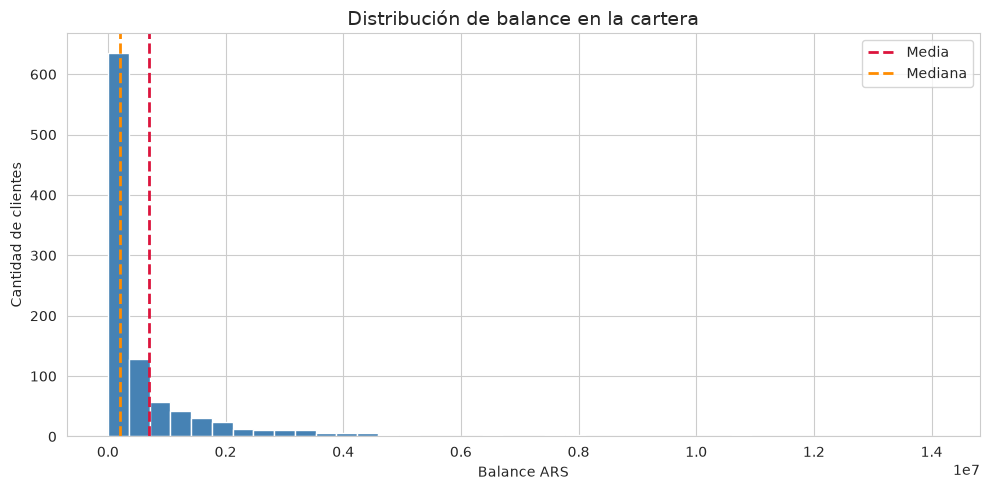

In [8]:
plt.figure(figsize=(10,5))
plt.hist(df['balance_ars'], bins=40, color='steelblue', edgecolor='white')
plt.axvline(df['balance_ars'].mean(), color='crimson', linestyle='--', linewidth=2, label='Media')
plt.axvline(df['balance_ars'].median(), color='darkorange', linestyle='--', linewidth=2, label='Mediana')
plt.title('Distribución de balance en la cartera', fontsize=14)
plt.xlabel('Balance ARS')
plt.ylabel('Cantidad de clientes')
plt.legend()
plt.tight_layout()
plt.show()

**Lectura esperada:** distribución asimétrica a la derecha (cola larga). La mayoría tiene balances chicos
y unos pocos concentran montos muy altos. Consecuencia práctica: para esta variable **la mediana describe
mejor al cliente típico** que la media.

Es el mismo fenómeno que ven en cualquier distribución de ingresos, y verlo dibujado convence
mucho más que explicarlo con números.

---
## Ejercicio 8 · Poner a prueba una hipótesis

Retail: antigüedad de los que se van vs los que se quedan. Y el mismo corte en Joven.

In [9]:
retail = df[df['segmento'] == 'Retail']

comparacion = retail.groupby('churn')['antiguedad_años'].agg(['mean','median','count']).round(2)
comparacion.index = ['Se quedaron', 'Se fueron']
print('SEGMENTO RETAIL')
print(comparacion)

# El mismo corte sobre Joven
joven = df[df['segmento'] == 'Joven']
comp_joven = joven.groupby('churn')['antiguedad_años'].agg(['mean','median','count']).round(2)
comp_joven.index = ['Se quedaron', 'Se fueron']
print('\nSEGMENTO JOVEN')
print(comp_joven)

SEGMENTO RETAIL
             mean  median  count
Se quedaron  4.49     3.5    344
Se fueron    3.27     2.0     76

SEGMENTO JOVEN
             mean  median  count
Se quedaron  1.22     1.0    149
Se fueron    1.15     0.9     91


**En Retail la hipótesis se confirma:** los que se fueron tienen ~3,3 años de antigüedad promedio
contra ~4,5 de los que se quedaron, y la mediana separa todavía más (2,0 vs 3,5). Con 344 y 76 casos,
la base alcanza para decirlo.

**Lectura de negocio:** el problema no está en el producto maduro, está en los **primeros años**.
La ventana de riesgo es temprana, y ahí es donde va el esfuerzo de retención — no en una campaña
genérica a todo el segmento.

**En Joven no se ve nada**, y ese es el segundo hallazgo del ejercicio: en Joven *todos* tienen
poca antigüedad (~1,2 años), así que no hay variación que pueda explicar nada.

> *"Una variable sin varianza no explica nada. Si todos tus clientes tienen el mismo valor en una
> columna, esa columna no te va a distinguir a los que se van de los que se quedan — por más que
> sea la causa correcta en otro segmento."*

Es un concepto que vale más que el resultado, y es la primera vez que aparece en el curso.

**Paso que suele costar:** filtrar primero y agrupar después, sobre el subconjunto. Es la primera vez
que encadenan dos operaciones sobre el mismo objeto.

---
## Ejercicio 9 · Cuidado con las bases chicas

Top 5 provincias por tasa de churn, con cantidad de clientes.

In [10]:
churn_prov = df.groupby('provincia').agg(
    clientes=('cliente_id', 'count'),
    tasa_churn=('churn', 'mean')
)
churn_prov['tasa_churn_%'] = (churn_prov['tasa_churn'] * 100).round(1)
churn_prov = churn_prov.sort_values('tasa_churn', ascending=False)

print('TOP 5 POR TASA DE CHURN')
print(churn_prov[['clientes','tasa_churn_%']].head())

print('\nMISMO RANKING, SOLO PROVINCIAS CON MÁS DE 50 CLIENTES')
print(churn_prov[churn_prov['clientes'] > 50][['clientes','tasa_churn_%']].head())

TOP 5 POR TASA DE CHURN
              clientes  tasa_churn_%
provincia                           
Tucumán             45          31.1
Entre Ríos          65          26.2
Buenos Aires       268          22.8
Santa Fe           113          22.1
Mendoza             81          18.5

MISMO RANKING, SOLO PROVINCIAS CON MÁS DE 50 CLIENTES
              clientes  tasa_churn_%
provincia                           
Entre Ríos          65          26.2
Buenos Aires       268          22.8
Santa Fe           113          22.1
Mendoza             81          18.5
Córdoba            153          17.0


**Lectura esperada — y el punto del ejercicio:** hay que mirar la columna `clientes` **antes** de sacar
conclusiones. Una provincia con 20 clientes y 40% de churn son 8 personas: puede ser puro ruido.
**Tasa alta sobre base chica no es una señal, es una casualidad.**

---
## Ejercicio 10 · Desafío — ¿a quién llamamos primero?

Balance en riesgo por segmento = balance total × tasa de churn.

In [11]:
resumen = df.groupby('segmento').agg(
    clientes=('cliente_id', 'count'),
    tasa_churn=('churn', 'mean'),
    balance_total=('balance_ars', 'sum'),
    balance_prom=('balance_ars', 'mean')
)

# La columna nueva: cuánta plata está efectivamente en riesgo en cada segmento
resumen['balance_en_riesgo'] = resumen['balance_total'] * resumen['tasa_churn']
resumen = resumen.sort_values('balance_en_riesgo', ascending=False)

vista = resumen.copy()
vista['tasa_churn'] = vista['tasa_churn'].apply(lambda x: f'{x:.1%}')
vista['balance_total'] = vista['balance_total'].apply(lambda x: f'${x/1e6:,.1f}M')
vista['balance_prom'] = vista['balance_prom'].apply(lambda x: f'${x:,.0f}')
vista['balance_en_riesgo'] = vista['balance_en_riesgo'].apply(lambda x: f'${x/1e6:,.1f}M')
print(vista.to_string())

          clientes tasa_churn balance_total balance_prom balance_en_riesgo
segmento                                                                  
Premium        180       7.2%       $409.3M   $2,273,940            $29.6M
Retail         420      18.1%       $108.9M     $259,287            $19.7M
PyME           160      11.9%       $159.1M     $994,116            $18.9M
Joven          240      37.9%        $15.6M      $65,100             $5.9M


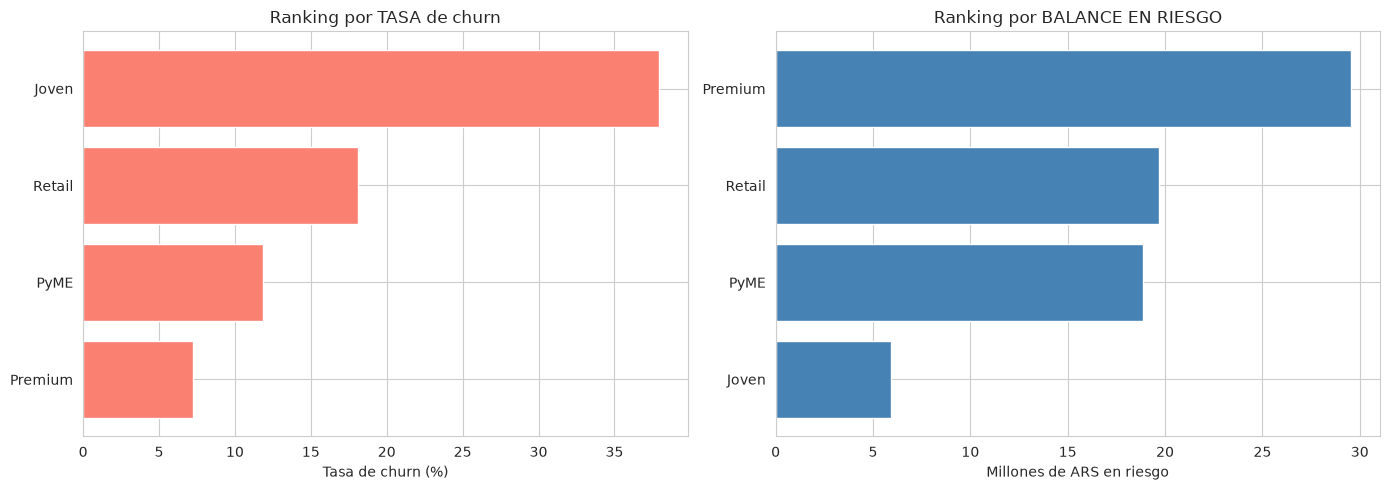

Mayor tasa de churn : Joven
Mayor balance en riesgo: Premium


In [12]:
# El gráfico: qué segmento pone más plata en riesgo
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

orden_tasa = resumen.sort_values('tasa_churn')
axes[0].barh(orden_tasa.index, orden_tasa['tasa_churn'] * 100, color='salmon')
axes[0].set_title('Ranking por TASA de churn')
axes[0].set_xlabel('Tasa de churn (%)')

orden_riesgo = resumen.sort_values('balance_en_riesgo')
axes[1].barh(orden_riesgo.index, orden_riesgo['balance_en_riesgo'] / 1e6, color='steelblue')
axes[1].set_title('Ranking por BALANCE EN RIESGO')
axes[1].set_xlabel('Millones de ARS en riesgo')

plt.tight_layout()
plt.show()

print('Mayor tasa de churn :', resumen['tasa_churn'].idxmax())
print('Mayor balance en riesgo:', resumen['balance_en_riesgo'].idxmax())

### Recomendación modelo

**El punto del desafío:** el segmento con **la tasa más alta** no tiene por qué ser el de **mayor plata
en riesgo**. Un segmento masivo de tickets chicos puede fugar mucho en porcentaje y poco en pesos;
uno chico y rico puede fugar poco y doler más.

Los dos gráficos lado a lado son la respuesta: si los rankings coinciden, la decisión es fácil;
si no coinciden, ahí está la conversación interesante.

**Modelo de los tres bullets:**

1. **El problema** — se fue el X% de la cartera, equivalente a $Y millones de balance
2. **El foco** — el segmento [A] tiene la tasa más alta, pero el segmento [B] concentra el mayor
   balance en riesgo. La campaña va a [B], porque el mismo esfuerzo protege más valor
3. **La acción** — [qué haría la campaña concretamente: beneficio, canal, momento]